# Raul vs mistsim: `main` versus PR 12

Compares Raul's reference simulator against mistsim run under two
environments: `main` (croissant 5.1.4) and this branch (croissant
v5.3.0.dev2, PR 12).

**Run this notebook twice** — once under the `mistsim (croissant
5.1.4)` kernel, once under the project kernel. It tags its own output
by the croissant revision it detects, and the comparison section
renders whichever tagged results exist. The second run is the complete
artifact.

The two environments differ in croissant, s2fft **and** jax together;
they cannot be separated cheaply because croissant 5.1.4 and PyPI
s2fft both require `jax<0.6`. This notebook therefore measures *`main`
versus PR 12*, not the pole-of-date fix in isolation.


In [1]:
import json
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import importlib.metadata as md

import astropy.units as u
import croissant as cro
import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.time import Time

import mistsim as ms

%matplotlib inline

REPO = Path("/home/christian/Documents/research/MIST/mistsim")
DATA_DIR = REPO / "data"
OUT_DIR = REPO / "notebooks/sim_comparisons/results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Astronomical azimuth of the beam X-axis. The FEKO beam has
# phi=0=North, so 0 is correct; see beam.py (beam_rot = az_rot - 90).
BEAM_AZ_ROT = 0

# This notebook never writes to data/. beam.npz there is a live
# mapmaking input (mars-lake-dip in runs.yaml).
WRITE_SHARED_INPUTS = False

NSIDE = 128
SIM_LMAX = 100

TESTS = {
    0: "MARS / with mountains",
    1: "MARS / no mountains",
    2: "North Pole / no mountains",
}


In [2]:
def croissant_tag():
    """Machine tag and human label for the installed croissant.

    The v5.3.0.dev2 tag still reports __version__ == "5.2.1", so the
    version string alone cannot distinguish the environments. Prefer
    the git revision the installer recorded; fall back to probing for
    eq2cirs, which exists only after the bump.
    """
    version = md.version("croissant-sim")
    rev = None
    try:
        raw = md.distribution("croissant-sim").read_text(
            "direct_url.json"
        )
        if raw:
            rev = json.loads(raw).get("vcs_info", {}).get("commit_id")
    except Exception:
        rev = None
    tag = f"{version}+git{rev[:7]}" if rev else version
    is_new = hasattr(cro.rotations, "eq2cirs")
    label = (
        "PR 12 (croissant v5.3.0.dev2)"
        if is_new
        else "main (croissant 5.1.4)"
    )
    return tag, label


TAG, LABEL = croissant_tag()
print(f"TAG   = {TAG}")
print(f"LABEL = {LABEL}")
print(f"jax   = {jax.__version__}")


TAG   = 5.2.1+gitd972c5f
LABEL = PR 12 (croissant v5.3.0.dev2)
jax   = 0.11.1


In [3]:
def read_raul(path):
    with h5py.File(path, "r") as hf:
        return (
            np.array(hf["lst"]),
            np.array(hf["freq"]),
            np.array(hf["ant_temp"]),
        )


paths = {
    0: "20260215_for_christian/antenna_temperature_20260215_test1.hdf5",
    1: "20260220_for_christian/antenna_temperature_20260220_test1.hdf5",
    2: "20260220_for_christian/antenna_temperature_20260220_test2.hdf5",
}

raul, lsts = {}, {}
freqs = None
for k, rel in paths.items():
    lst_k, freq_k, temp_k = read_raul(DATA_DIR / rel)
    if freqs is None:
        freqs = freq_k
    assert np.allclose(freq_k, freqs), f"freq mismatch in test {k}"
    assert temp_k.shape == (lst_k.size, freqs.size), (
        f"test {k}: got {temp_k.shape}"
    )
    raul[k], lsts[k] = temp_k, lst_k

# Tests 0 and 1 share a MARS LST grid; test 2 is the North Pole grid.
assert np.allclose(lsts[0], lsts[1])
print(f"freqs {freqs.shape}: {freqs[0]:.0f}-{freqs[-1]:.0f} MHz")
for k in raul:
    print(f"test {k}: {raul[k].shape}, LST "
          f"{lsts[k][0]:.2f}-{lsts[k][-1]:.2f} hr")


freqs (86,): 40-125 MHz
test 0: (241, 86), LST 0.08-23.98 hr
test 1: (241, 86), LST 0.08-23.98 hr
test 2: (241, 86), LST 0.03-23.93 hr


In [4]:
def load_haslam():
    path = (
        DATA_DIR
        / "20260215_for_christian/haslam408_ds_Remazeilles2014.fits"
    )
    with fits.open(path) as hdul:
        return hdul[1].data["TEMPERATURE"].ravel()


def scale_map(m, freqs, beta=-2.55, f0=408, tcmb=2.725):
    scale = (freqs / f0) ** beta
    return (m - tcmb)[None, :] * scale[:, None] + tcmb


haslam = hp.ud_grade(load_haslam(), NSIDE, order_in="RING")
haslam = scale_map(haslam, freqs)
sky_model = ms.Sky(haslam, freqs, sampling="healpix", coord="galactic")
print(f"sky {sky_model.data.shape}")


sky (86, 196608)


data/beam.npz left untouched (WRITE_SHARED_INPUTS=False)


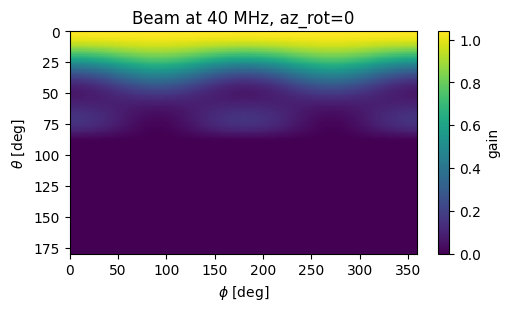

In [5]:
d = np.load(DATA_DIR / "feko_beam.npz")
theta = d["theta"]
assert theta.max() <= np.pi * (1 + 1e-6), (
    "feko_beam.npz must store theta in radians"
)

fix = np.isin(d["freqs"] / 1e6, freqs)
gain_above = d["gain"][fix]
assert np.allclose(d["freqs"][fix] / 1e6, freqs)

# Extend theta to 180 deg with zero gain below the horizon.
gain = np.concatenate(
    (gain_above, np.zeros_like(gain_above[:, :-1, :])), axis=1
)
theta_full = np.concatenate(
    (theta, np.deg2rad(np.arange(91, 181)))
)

horizon = (theta_full <= np.deg2rad(80))[:, None]
beam_mtn = ms.Beam(
    gain, freqs, sampling="mwss", horizon=horizon,
    beam_az_rot=BEAM_AZ_ROT,
)
beam_flat = ms.Beam(
    gain, freqs, sampling="mwss", horizon=None,
    beam_az_rot=BEAM_AZ_ROT,
)
beams = {0: beam_mtn, 1: beam_flat, 2: beam_flat}

if WRITE_SHARED_INPUTS:
    np.savez(
        DATA_DIR / "beam.npz",
        freqs=d["freqs"][fix] / 1e6, phi=d["phi"],
        theta=theta_full, gain=gain,
    )
else:
    print("data/beam.npz left untouched (WRITE_SHARED_INPUTS=False)")

plt.figure(figsize=(5, 3), constrained_layout=True)
plt.imshow(gain[0], aspect="auto", interpolation="none",
           extent=[0, 359, 180, 0])
plt.colorbar(label="gain")
plt.title(f"Beam at {freqs[0]:.0f} MHz, az_rot={BEAM_AZ_ROT}")
plt.xlabel(r"$\phi$ [deg]")
plt.ylabel(r"$\theta$ [deg]")
plt.show()


In [6]:
mars = EarthLocation.from_geodetic(-90.74750, 79.41833, height=150)
npole = EarthLocation.from_geodetic(0, 90, height=0)
locs = {0: mars, 1: mars, 2: npole}


def lst_to_time(lst_arr, t0):
    """Convert an array of LST in hours to astropy Times."""
    lst_ref = t0.sidereal_time("mean").hour
    return t0 + (lst_arr - lst_ref) / 24 * u.sday


times = {}
for k, loc in locs.items():
    t0 = Time("2022-07-17 00:00", location=loc)
    times[k] = lst_to_time(lsts[k], t0)
    got = times[k].sidereal_time("mean").hour
    assert np.allclose(got, lsts[k]), f"LST mismatch in test {k}"
print("LST round-trip OK for all three tests")


LST round-trip OK for all three tests


In [7]:
cache_path = OUT_DIR / f"raul_cmp_{TAG}.npz"

if cache_path.exists():
    print(f"Loading cached {cache_path.name}")
    c = np.load(cache_path, allow_pickle=True)
    mine = {k: c[f"test{k}"] for k in TESTS}
else:
    mine = {}
    for k in TESTS:
        print(f"Simulating test {k}: {TESTS[k]}")
        sim = ms.Simulator(
            beams[k], sky_model, times[k].jd, freqs,
            locs[k].lon.deg, locs[k].lat.deg,
            alt=locs[k].height.value, lmax=SIM_LMAX, Tgnd=0,
        )
        tant = sim.sim()
        fgnd = sim.beam.compute_fgnd()
        mine[k] = np.asarray(
            cro.simulator.correct_ground_loss(tant, fgnd, 0)
        )
    np.savez(
        cache_path,
        test0=mine[0], test1=mine[1], test2=mine[2],
        lst0=lsts[0], lst2=lsts[2], freqs=freqs,
        tag=TAG, label=LABEL, beam_az_rot=BEAM_AZ_ROT,
    )
    print(f"Wrote {cache_path}")

for k in TESTS:
    assert mine[k].shape == raul[k].shape, (
        f"test {k}: {mine[k].shape} vs Raul {raul[k].shape}"
    )
print("All three waterfalls match Raul's shape")


Loading cached raul_cmp_5.2.1+gitd972c5f.npz
All three waterfalls match Raul's shape


In [8]:
runs = []
for path in sorted(OUT_DIR.glob("raul_cmp_*.npz")):
    c = np.load(path, allow_pickle=True)
    runs.append({
        "tag": str(c["tag"]),
        "label": str(c["label"]),
        "az_rot": float(c["beam_az_rot"]),
        "data": {k: c[f"test{k}"] for k in TESTS},
    })
    print(f"{c['label']}  (az_rot={float(c['beam_az_rot']):.0f})")

if len(runs) < 2:
    print(
        "\nOnly one environment present. Re-run this notebook under "
        "the other kernel to populate the comparison."
    )


PR 12 (croissant v5.3.0.dev2)  (az_rot=0)

Only one environment present. Re-run this notebook under the other kernel to populate the comparison.


In [9]:
def residual_profile(mine, ref, lst):
    """Agreement with the reference, and how it varies across the day.

    Per croissant's CHANGELOG entry for the pole-of-date change, the
    pre-bump pointing error was zero at times_jd[0], grew to ~17' by
    mid-day, and closed again after a full sidereal day. If a
    time-varying effect like that dominates the disagreement, the
    per-LST residual traces an arch and arch_ratio is well above 1. A
    flat profile (arch_ratio ~ 1) means the disagreement is something
    else. This does not attribute an observed arch to any specific
    fix -- it only characterizes the shape of the residual.
    """
    resid = np.asarray(mine) - np.asarray(ref)
    per_lst = np.mean(np.abs(resid), axis=1)
    n = per_lst.size
    third = max(n // 3, 1)
    half = third // 2
    if half > 0:
        edges = np.concatenate([per_lst[:half], per_lst[n - half:]])
        edge_mean = float(np.mean(edges))
    else:
        # Too few samples for an edge window: `per_lst[-0:]` would
        # otherwise silently alias to the whole array.
        edge_mean = float("nan")
    middle = per_lst[third: 2 * third]
    middle_mean = float(np.mean(middle))
    mean_abs = float(np.mean(np.abs(resid)))
    # Guard against a near-zero (not just exactly-zero) edge mean:
    # dividing by it gives an arbitrarily large, meaningless ratio in
    # precisely the regime this metric exists to flag. "Negligible"
    # is defined relative to the overall residual scale (mean_abs_K)
    # rather than a bare absolute constant.
    edge_floor = 1e-3 * mean_abs
    arch_ratio = (
        middle_mean / edge_mean
        if edge_mean > edge_floor
        else float("nan")
    )
    return {
        "mean_abs_K": mean_abs,
        "max_abs_K": float(np.max(np.abs(resid))),
        # Ratio of means, not a mean of per-point relative errors:
        # over the ~500-12000 K range spanned here, mean(|resid|) /
        # mean(|ref|) is far better behaved than averaging per-point
        # percent errors, which blow up as ref -> 0.
        "mean_rel_pct": float(100 * mean_abs / np.mean(np.abs(ref))),
        "edge_mean_K": edge_mean,
        "middle_mean_K": middle_mean,
        "arch_ratio": arch_ratio,
        "per_lst": per_lst,
    }


In [10]:
hdr = (
    f"{'test':<28} {'environment':<30} {'mean K':>8} "
    f"{'ratio %':>7} {'max K':>9} {'arch':>6}"
)
print(hdr)
print("-" * len(hdr))
profiles = {}
for k in TESTS:
    for run in runs:
        p = residual_profile(run["data"][k], raul[k], lsts[k])
        profiles[(k, run["tag"])] = p
        print(
            f"{TESTS[k]:<28} {run['label']:<30} "
            f"{p['mean_abs_K']:8.3f} {p['mean_rel_pct']:7.2f} "
            f"{p['max_abs_K']:9.3f} {p['arch_ratio']:6.2f}"
        )
    print()


test                         environment                      mean K ratio %     max K   arch
---------------------------------------------------------------------------------------------
MARS / with mountains        PR 12 (croissant v5.3.0.dev2)     1.303    0.05    14.708   1.42

MARS / no mountains          PR 12 (croissant v5.3.0.dev2)     0.921    0.03     7.738   1.15

North Pole / no mountains    PR 12 (croissant v5.3.0.dev2)   117.527    4.30   548.351   1.00



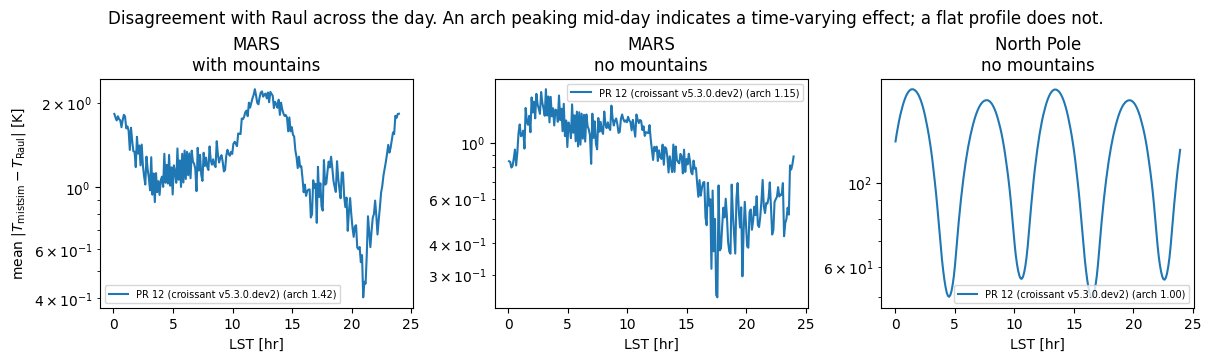

In [11]:
fig, axs = plt.subplots(
    nrows=1, ncols=3, figsize=(12, 3.5), sharex=False,
    constrained_layout=True,
)
for ax, k in zip(axs, TESTS):
    for run in runs:
        p = profiles[(k, run["tag"])]
        ax.plot(
            lsts[k], p["per_lst"],
            label=f"{run['label']} (arch {p['arch_ratio']:.2f})",
        )
    ax.set_title("\n".join(TESTS[k].split(" / ")))
    ax.set_xlabel("LST [hr]")
    ax.set_yscale("log")
axs[0].set_ylabel(r"mean $|T_{\rm mistsim} - T_{\rm Raul}|$ [K]")
for ax in axs:
    ax.legend(fontsize=7)
fig.suptitle(
    "Disagreement with Raul across the day. An arch peaking mid-day "
    "indicates a time-varying effect; a flat profile does not."
)
plt.show()


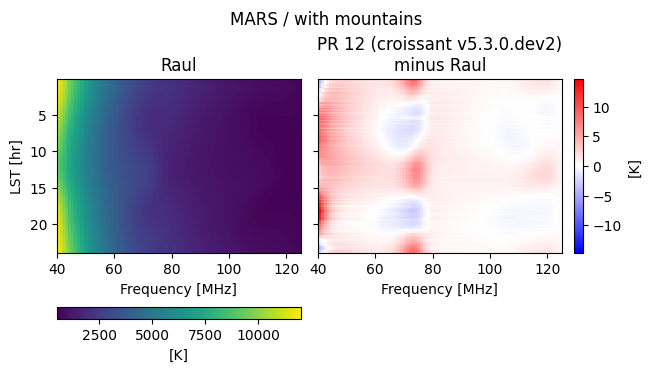

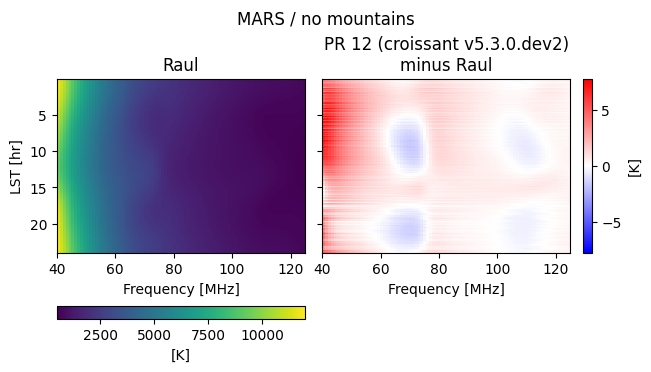

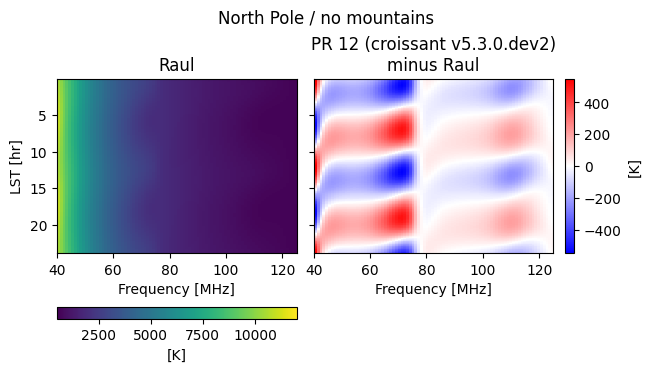

In [12]:
for k in TESTS:
    ncols = 1 + len(runs)
    fig, axs = plt.subplots(
        nrows=1, ncols=ncols, figsize=(3.2 * ncols, 3.6),
        sharey=True, constrained_layout=True,
    )
    ext = [freqs[0], freqs[-1], lsts[k][-1], lsts[k][0]]
    kw = dict(extent=ext, interpolation="none", aspect="auto")
    im = axs[0].imshow(raul[k], vmin=500, vmax=12000, **kw)
    axs[0].set_title("Raul")
    axs[0].set_ylabel("LST [hr]")
    # One shared colour scale across every run's residual panel for
    # this test, so panels are directly comparable by eye instead of
    # each floating on its own vmin/vmax.
    d_ims = [run["data"][k] - raul[k] for run in runs]
    lim = max(np.max(np.abs(d_im)) for d_im in d_ims)
    im2 = None
    for ax, run, d_im in zip(axs[1:], runs, d_ims):
        im2 = ax.imshow(d_im, cmap="bwr", vmin=-lim, vmax=lim, **kw)
        ax.set_title(f"{run['label']}\nminus Raul")
    for ax in axs:
        ax.set_xlabel("Frequency [MHz]")
    fig.colorbar(im, ax=axs[0], label="[K]", location="bottom")
    if im2 is not None:
        fig.colorbar(im2, ax=axs[1:], label="[K]")
    fig.suptitle(TESTS[k])
    plt.show()


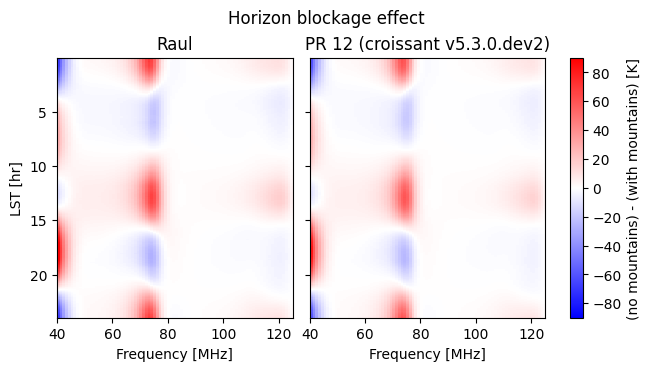

In [13]:
fig, axs = plt.subplots(
    nrows=1, ncols=1 + len(runs), figsize=(3.2 * (1 + len(runs)), 3.6),
    sharey=True, constrained_layout=True,
)
ext = [freqs[0], freqs[-1], lsts[0][-1], lsts[0][0]]
kw = dict(extent=ext, interpolation="none", aspect="auto",
          cmap="bwr", vmin=-90, vmax=90)
im = axs[0].imshow(raul[1] - raul[0], **kw)
axs[0].set_title("Raul")
axs[0].set_ylabel("LST [hr]")
for ax, run in zip(axs[1:], runs):
    ax.imshow(run["data"][1] - run["data"][0], **kw)
    ax.set_title(run["label"])
for ax in axs:
    ax.set_xlabel("Frequency [MHz]")
fig.colorbar(im, ax=axs, label="(no mountains) - (with mountains) [K]")
fig.suptitle("Horizon blockage effect")
plt.show()


## Beam convention sanity check

`beam_az_rot` is the astronomical azimuth of the beam X-axis
(0 = North), converted internally to croissant's convention via
`beam_rot = beam_az_rot - 90`. The FEKO beam has phi=0 = North, so 0
is correct.

Passing 90 instead puts the beam 90 degrees out, which for this
dipole's two-fold symmetry is the *maximally* wrong rotation: it
produces a ~130 K disagreement with Raul rather than the ~1 K the
correct convention gives. Set `RUN_CONVENTION_CHECK = True` to
reproduce that, so the convention stays documented rather than
tribal knowledge.

In [14]:
RUN_CONVENTION_CHECK = False

if RUN_CONVENTION_CHECK:
    bad = ms.Beam(
        gain, freqs, sampling="mwss",
        horizon=(theta_full <= np.deg2rad(80))[:, None],
        beam_az_rot=90,
    )
    sim = ms.Simulator(
        bad, sky_model, times[0].jd, freqs,
        locs[0].lon.deg, locs[0].lat.deg,
        alt=locs[0].height.value, lmax=SIM_LMAX, Tgnd=0,
    )
    wrong = np.asarray(
        cro.simulator.correct_ground_loss(
            sim.sim(), sim.beam.compute_fgnd(), 0
        )
    )
    p_bad = residual_profile(wrong, raul[0], lsts[0])
    p_good = profiles[(0, TAG)]
    print(f"az_rot=0  : {p_good['mean_abs_K']:8.3f} K")
    print(f"az_rot=90 : {p_bad['mean_abs_K']:8.3f} K")
else:
    print("Convention check disabled (RUN_CONVENTION_CHECK=False)")

Convention check disabled (RUN_CONVENTION_CHECK=False)
